In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("data/processed/comptages_features.csv", sep=",") 

df.head()

,libelle,q,k,etat_trafic,libelle_nd_amont,libelle_nd_aval,Dates_Paris,heure,jour_semaine,weekend,mois,barre_Barré,barre_Invalide,barre_Ouvert,aberrant_iqr
0,Bd_Macdonald,94.0,NaN,NaN,Bd Macdonald-Allee des Cardinoux,Bd_Macdonald - Jaques Duchesne,2026-09-01 01:00:00+02:00,1,1,False,9,False,False,True,False
1,Bd_Macdonald,94.0,0.52500,0.0,Bd_Macdonald - Jaques Duchesne,Bd_Macdonald - Lounes Matoub,2026-09-01 01:00:00+02:00,1,1,False,9,False,False,True,False
2,Bd_Macdonald,NaN,0.51833,0.0,Bd_Macdonald - Chana Orloff,Bd_Macdonald - Lounes Matoub,2026-09-01 01:00:00+02:00,1,1,False,9,False,False,True,False
3,Bd_Macdonald,48.0,NaN,NaN,Bd_Macdonald - Lounes Matoub,Bd Macdonald - Rue E. 019,2026-09-01 01:00:00+02:00,1,1,False,9,False,False,True,False
4,Bd_Macdonald,19.0,NaN,NaN,Macdonald-Parc_Villette,Macdonald-Cariou,2026-09-01 01:00:00+02:00,1,1,False,9,False,False,True,False


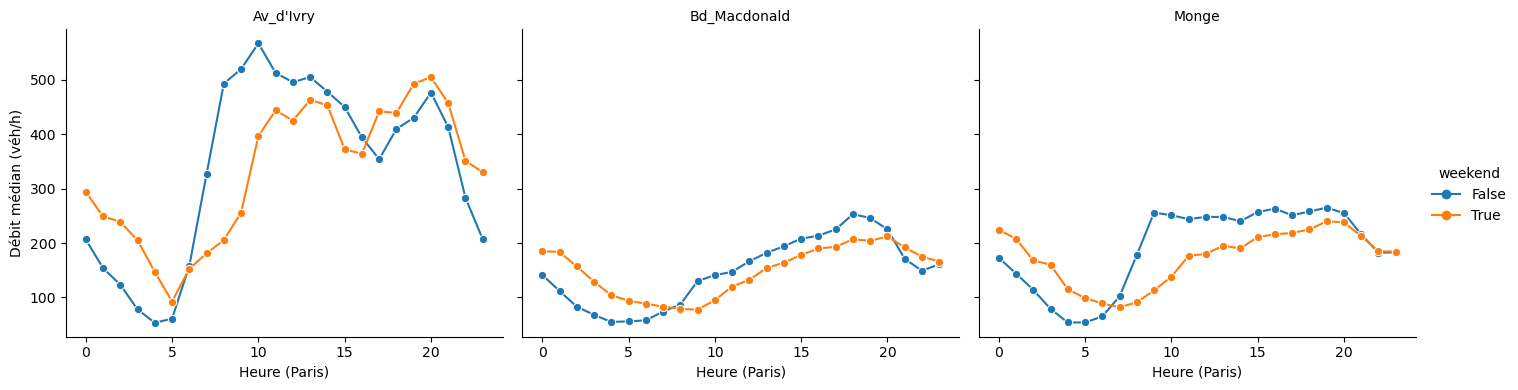

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Préparation : calcul du débit médian par axe, heure et type de jour (semaine / week-end)
df_agg = df.groupby(["libelle", "heure", "weekend"], observed=True)["q"].median().reset_index()

# Création du graphique à facettes
g = sns.relplot(
    data=df_agg,
    x="heure",
    y="q",
    hue="weekend",
    col="libelle",
    kind="line",
    marker="o",
    height=4,
    aspect=1.2,
    facet_kws={"sharey": True}
)

g.set_axis_labels("Heure (Paris)", "Débit médian (véh/h)")
g.set_titles(col_template="{col_name}")
plt.show()

`Av_d'Ivry` : On observe de forts volumes de trafic en semaine avec un pic de débit marqué autour de 10h (dépassant 550 véh/h), tandis que le week-end montre un profil plus étalé et un second pic en soirée vers 20h.

`Bd_Macdonald` : Le profil est beaucoup plus plat et bas en termes de débit (généralement entre 50 et 250 véh/h), avec une légère augmentation progressive l'après-midi et en début de soirée, sans différence importante entre semaine et week-end.

`Monge` : En semaine, le débit monte rapidement le matin vers 9h-10h pour se stabiliser à un plateau élevé (~250 véh/h) tout au long de la journée avant de redescendre le soir. Le week-end, la montée en charge est plus progressive et remarqué plus tardivement.

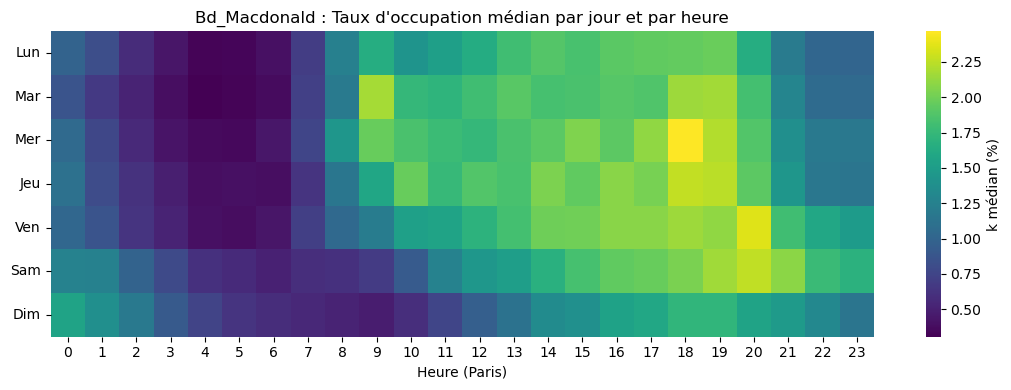

In [4]:
# Sélection d'un axe spécifique
axe = "Bd_Macdonald"
sub_df = df[df["libelle"] == axe]

# Création du tableau pivot en utilisant directement la colonne 'jour_semaine' existante
pivot_table = sub_df.pivot_table(
    index="jour_semaine", columns="heure", values="k", aggfunc="median"
)

# Configuration de la figure
plt.figure(figsize=(11, 4))
sns.heatmap(pivot_table, cmap="viridis", cbar_kws={"label": "k médian (%)"})

plt.title(f"{axe} : Taux d'occupation médian par jour et par heure")
plt.xlabel("Heure (Paris)")
plt.ylabel("")

# Étiquettes personnalisées pour les jours de la semaine
plt.yticks(
    ticks=[0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5],
    labels=["Lun", "Mar", "Mer", "Jeu", "Ven", "Sam", "Dim"],
    rotation=0,
)

plt.tight_layout()
plt.show()

On observe une nette concentration de la charge en fin de journée de la semaine, avec une zone très intense qui s'étale entre 17h et 20h du mardi au vendredi. À l'inverse, les matinées et les nuits sont particulièrement calmes.

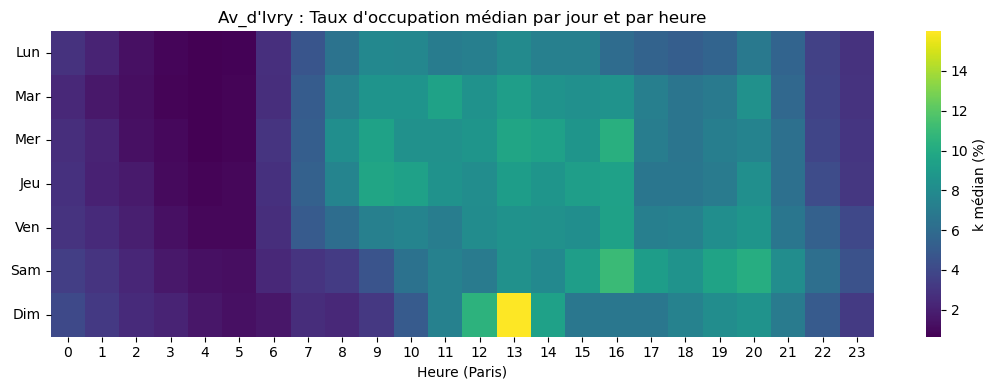

In [5]:
# Sélection d'un axe spécifique
axe = "Av_d'Ivry"
sub_df = df[df["libelle"] == axe]

# Création du tableau pivot en utilisant directement la colonne 'jour_semaine' existante
pivot_table = sub_df.pivot_table(
    index="jour_semaine", columns="heure", values="k", aggfunc="median"
)

# Configuration de la figure
plt.figure(figsize=(11, 4))
sns.heatmap(pivot_table, cmap="viridis", cbar_kws={"label": "k médian (%)"})

plt.title(f"{axe} : Taux d'occupation médian par jour et par heure")
plt.xlabel("Heure (Paris)")
plt.ylabel("")

# Étiquettes personnalisées pour les jours de la semaine
plt.yticks(
    ticks=[0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5],
    labels=["Lun", "Mar", "Mer", "Jeu", "Ven", "Sam", "Dim"],
    rotation=0,
)

plt.tight_layout()
plt.show()

Contrairement à la rue Monge, le profil est beaucoup plus différent. Du lundi au vendredi, on observe une légère augmentation de la charge en journée (autour de 9h-15h), mais avec des niveaux qui restent modérés. Le fait le plus étonnant se produit le dimanche vers 13h, où l'on repère un pic d'occupation très intense (atteignant près de 15 %).

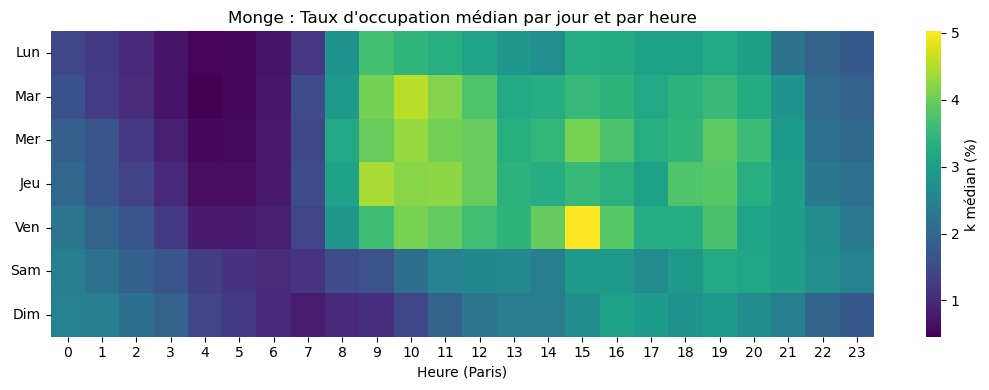

In [7]:
# Sélection d'un axe spécifique
axe = "Monge"
sub_df = df[df["libelle"] == axe]

# Création du tableau pivot en utilisant directement la colonne 'jour_semaine' existante
pivot_table = sub_df.pivot_table(
    index="jour_semaine", columns="heure", values="k", aggfunc="median"
)

# Configuration de la figure
plt.figure(figsize=(11, 4))
sns.heatmap(pivot_table, cmap="viridis", cbar_kws={"label": "k médian (%)"})

plt.title(f"{axe} : Taux d'occupation médian par jour et par heure")
plt.xlabel("Heure (Paris)")
plt.ylabel("")

# Étiquettes personnalisées pour les jours de la semaine
plt.yticks(
    ticks=[0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5],
    labels=["Lun", "Mar", "Mer", "Jeu", "Ven", "Sam", "Dim"],
    rotation=0,
)

plt.tight_layout()
plt.show()

On voit clairement un profil typique de semaine de travail, du lundi au vendredi, l'occupation reste très faible la nuit et tôt le matin, puis explose littéralement entre 9h et 13h (avec un gros pic autour de 10h-11h), et connaît un second paroxysme l'après-midi vers 15h le vendredi. À l'inverse, le week-end (samedi et dimanche) est beaucoup plus calme et étalé, sans ces fortes concentrations matinales en semaine.

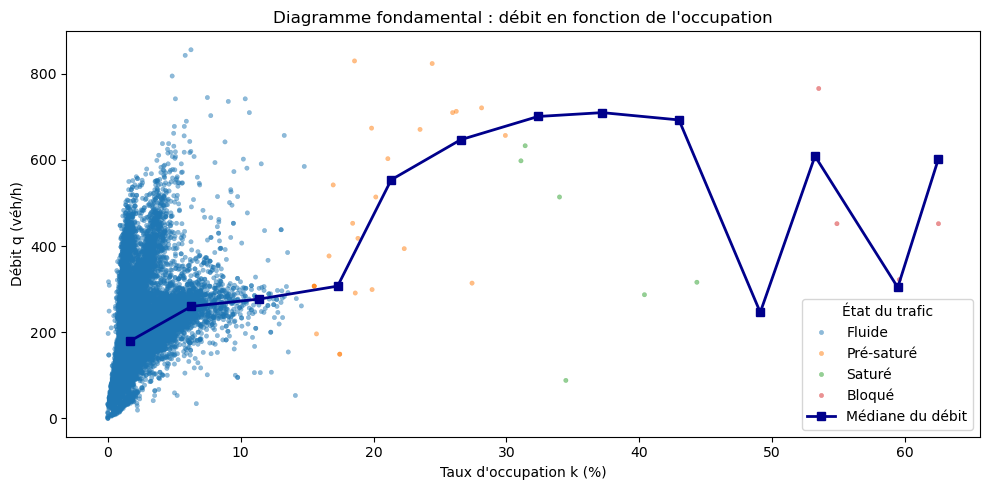

In [8]:
# Association des libellés aux états du trafic
etat_map = {0.0: "Fluide", 1.0: "Pré-saturé", 2.0: "Saturé", 3.0: "Bloqué"}
df["etat_label"] = df["etat_trafic"].map(etat_map)

# Échantillonnage aléatoire
echantillon = df.dropna(subset=["q", "k", "etat_label"]).sample(
    n=15000, random_state=42
)

plt.figure(figsize=(10, 5))

# Palette et ordre
palette_couleurs = {
    "Fluide": "#1f77b4",
    "Pré-saturé": "#ff7f0e",
    "Saturé": "#2ca02c",
    "Bloqué": "#d62728",
}
ordre_etats = ["Fluide", "Pré-saturé", "Saturé", "Bloqué"]

sns.scatterplot(
    data=echantillon,
    x="k",
    y="q",
    hue="etat_label",
    hue_order=ordre_etats,
    palette=palette_couleurs,
    s=10,
    alpha=0.5,
    edgecolor=None,
)

# Utilisation de pd.cut pour des tranches de 5% (comme dans votre cours)
classes = pd.cut(df["k"], bins=range(0, 101, 5))
med_q = df.groupby(classes, observed=True)["q"].median()
med_k = df.groupby(classes, observed=True)["k"].median()

# Tracé de la courbe médiane
plt.plot(
    med_k,
    med_q,
    color="darkblue",
    marker="s",
    linewidth=2,
    label="Médiane du débit",
)

plt.title("Diagramme fondamental : débit en fonction de l'occupation")
plt.xlabel("Taux d'occupation k (%)")
plt.ylabel("Débit q (véh/h)")
plt.legend(title="État du trafic")
plt.tight_layout()
plt.show()

Au début, quand le trafic est fluide (points bleus), le débit monte en flèche avec l'occupation jusqu'à un pic autour de 35-40 % où il atteint environ 700 véhicules par heure. Dès qu'on dépasse ce seuil critique et qu'on entre dans les zones pré-saturées et saturées (points oranges et verts), le débit commence à s'effondrer brutalement, ce qui montre la transition classique vers la congestion où les véhicules se bloquent et la route perd de sa capacité d'écoulement.

In [9]:
df.groupby("etat_trafic", observed=True)["k"].agg(["min","max"]).round(1)

,min,max
etat_trafic,,
0.0,0.0,15.0
1.0,15.1,29.9
2.0,30.0,49.7
3.0,52.6,68.7


In [10]:
# 2. Calcul et affichage textuel des seuils (min, max, moyenne de l'occupation k) par axe et par état du trafic
seuils = (
    df.groupby(['libelle', 'etat_trafic'])['k']
    .agg(['min', 'mean', 'max', 'count'])
    .reset_index()
)

print('--- Seuils d occupation par etat de trafic et par axe ---')
print(seuils.to_string(index=False))

--- Seuils d occupation par etat de trafic et par axe ---
     libelle  etat_trafic      min      mean      max  count
   Av_d'Ivry          0.0  0.00000  5.493608 14.85334   2637
   Av_d'Ivry          1.0 15.17223 19.883643 27.52000     63
   Av_d'Ivry          2.0 30.12000 31.152777 32.39611      3
Bd_Macdonald          0.0  0.00000  1.521662 14.82333  23954
Bd_Macdonald          1.0 15.06667 21.319073 29.91944     73
Bd_Macdonald          2.0 30.01945 37.341331 49.66500     33
Bd_Macdonald          3.0 52.62778 58.376557 68.71667     10
       Monge          0.0  0.00000  2.635474 14.98667  62926
       Monge          1.0 15.18889 17.894593 22.57111     68
       Monge          2.0 34.47500 42.079170 49.11056      8
       Monge          3.0 59.46056 59.460560 59.46056      2


Les seuils de passage en mode pré-saturé sont constants, autour de 15 % d'occupation partout, et la bascule vers la saturation tourne autour de 30 %. Par contre, la résistance des axes change radicalement, l'Avenue d'Ivry s'en sort bien et ne dépasse jamais 32 %, alors que le Boulevard Macdonald a des pointes de blocage qui montent jusqu'à près de 69 %. Vu le peu de lignes sur les états 1, 2 et 3 par rapport au reste, ça correspond juste aux gros pics d'embouteillages ponctuels aux heures de pointe.